# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Muhammad Geralldo Agatha Saputra
- **Email:** 24031554091@mhs.unesa.ac.id
- **ID Dicoding:** MUHAMMAD GERALLDO AGATHA SAPUTRA

## Menentukan Pertanyaan Bisnis

- Bagaimana pengaruh kondisi Heavy Rain/Snowdi bandingkan Clear terhadap penurunan jumlah penyewaan oleh pengguna asual?"
- Berapa rata-rata jumlah total sepeda yang disewa pada pukul 08.00 pagi dan 17.00 sore setiap harinya?
- Pada jam berapakah (hr) tingkat penyewaan sepeda mencapai titik terendah, sehingga waktu tersebut paling optimal untuk dijadikan jadwal maintenance sepeda harian
- Apakah terdapat perbedaan pola jumlah penyewaan sepeda antara hari holiday / akhir pekan dibandingkan dengan hari kerja biasa
- Bagaimana tren pertumbuhan persentase total penyewaan sepeda (cnt) per bulan (mnth) dari tahun 2011 dibandingkan dengan tahun 2012 (yr)

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [ ]:
df_day = pd.read_csv("day.csv")
df_hour = pd.read_csv("hour.csv")

df_day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [ ]:
df_hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


Dataset yang digunakan terdiri dari dua file:

- day.csv → data agregasi penyewaan sepeda per hari
- hour.csv → data penyewaan sepeda per jam

Dataset ini berisi informasi seperti:
- kondisi cuaca
- suhu
- kecepatan angin
- jumlah pengguna casual
- jumlah pengguna terdaftar
- total penyewaan sepeda

**Insight:**
- Dataset day memiliki 731 baris dan 16 kolom
- Dataset hour memiliki 17.379 baris dan 17 kolom
- Dataset hour memberikan informasi yang lebih detail untuk analisis jam sibuk

### Assessing Data

Melihat Struktur Data

In [ ]:
df_hour.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [ ]:
df_day.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


Mengecek Missing Values

In [ ]:
df_hour.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [ ]:
df_day.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


Statistika Deskriptif

In [ ]:
df_hour.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [ ]:
df_day.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:**
- Tidak ditemukan missing values signifikan pada dataset
- Struktur data sudah cukup rapi dan siap untuk dianalisis
- Variabel seperti season, weather, dan workingday bertipe numerik namun sebenarnya merepresentasikan kategori

### Cleaning Data

mengubah tipe data tanggal le format datetime

In [ ]:
df_day['dteday'] = pd.to_datetime(df_day['dteday'])
df_hour['dteday'] = pd.to_datetime(df_hour['dteday'])


Mengecek Duplicate

In [ ]:
df_day.duplicated().sum()

np.int64(0)

In [ ]:
df_hour.duplicated().sum()

np.int64(0)

Mapping Kategori Cuaca

In [ ]:
weather_labels = {
    1: "Clear",
    2: "Mist",
    3: "Light Rain/Snow",
    4: "Heavy Rain/Snow"
}

df_day["weather_mapping_label"] = df_day["weathersit"].map(weather_labels)
df_hour["weather_mapping_label"] = df_hour["weathersit"].map(weather_labels)

**Insight:**
- Data relatif bersih sehingga tidak memerlukan banyak preprocessing
- Transformasi kategori membantu interpretasi hasil analisis

## Exploratory Data Analysis (EDA)

### Explore Dataset

Statistik dasar penyewaan sepeda

In [ ]:
df_day[['casual','registered','cnt']].describe()

,casual,registered,cnt
count,731.000000,731.000000,731.000000
mean,848.176471,3656.172367,4504.348837
std,686.622488,1560.256377,1937.211452
min,2.000000,20.000000,22.000000
25%,315.500000,2497.000000,3152.000000
50%,713.000000,3662.000000,4548.000000
75%,1096.000000,4776.500000,5956.000000
max,3410.000000,6946.000000,8714.000000


**Insight:**
- Rata-rata harian registered (3656) jauh lebih tinggi dibanding casual (848). Artinya, mayoritas peminjaman berasal dari pengguna tetap.
- Casual hanya sekitar 19% dari total rata-rata. Namun, mereka bisa menjadi target potensial untuk dikonversi menjadi registered.
-   Mean (4504) hampir sama dengan median (4548), menunjukkan distribusi tidak terlalu skewed.

Distribusi Jumlah penyewaan

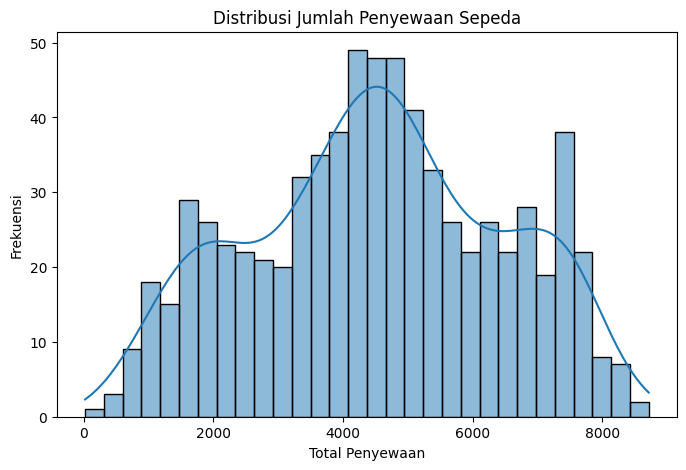

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df_day["cnt"], bins=30, kde=True)

plt.title("Distribusi Jumlah Penyewaan Sepeda")
plt.xlabel("Total Penyewaan")
plt.ylabel("Frekuensi")

plt.show()

**Insight:**
- Distribusi jumlah penyewaan sepeda harian secara keseluruhan terlihat normal di mana mayoritas hari memiliki total penyewaan di kisaran 4.000 hingga 5.000 unit.
- Tidak ditemukan adanya skewness atau outlier yang ekstrem, menandakan performa operasional bisnis penyewaan sepeda cenderung stabil setiap harinya.

Pola penyewaan berdasarkan jam

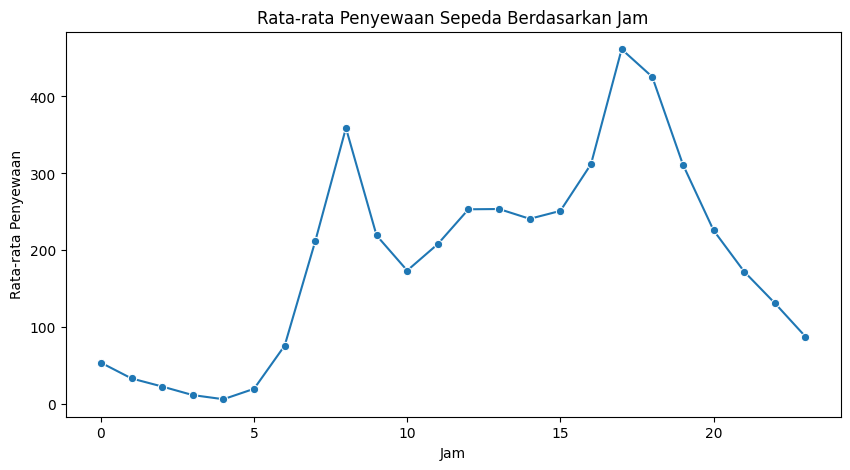

In [ ]:
hourly_rentals = df_hour.groupby("hr")["cnt"].mean()

plt.figure(figsize=(10,5))
sns.lineplot(x=hourly_rentals.index, y=hourly_rentals.values, marker="o")
plt.title("Rata-rata Penyewaan Sepeda Berdasarkan Jam")
plt.xlabel("Jam")
plt.ylabel("Rata-rata Penyewaan")
plt.show()

**Insight:**
- Grafik menunjukkan pola dua puncak yang sangat tegas. Lonjakan penyewaan terjadi pada pukul 08:00 pagi dan 17:00 sore, yang mana berkorelasi langsung dengan waktu berangkat dan pulang jam kantor.
- Waktu dengan aktivitas penyewaan paling sepi berada pada dini hari, yaitu antara pukul 00:00 hingga 05:00 pagi.

Penyewaan Berdasarkan Cuaca

In [ ]:
weather_rentals = df_day.groupby("weather_mapping_label")["cnt"].mean().sort_values()
weather_rentals

,cnt
weather_mapping_label,
Light Rain/Snow,1803.285714
Mist,4035.862348
Clear,4876.786177


**Insight:**
- Penyewaan terbanyak terjadi pada saat cuaca cerah (Clear) dengan rata-rata nyaris menyentuh 4.876 penyewaan.
- Saat cuaca memburuk menjadi Hujan Ringan/Salju (Light Rain/Snow), jumlah penyewaan anjlok drastis ke angka rata-rata 1.803. Bahkan tidak ada penyewaan sama sekali di hari dengan cuaca sangat ekstrem.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Pengaruh Cuaca terhadap Pengguna Casual

In [ ]:
weather_casual = df_day.groupby("weathersit")["casual"].mean()
weather_casual

,casual
weathersit,
1,964.030238
2,687.352227
3,185.476190


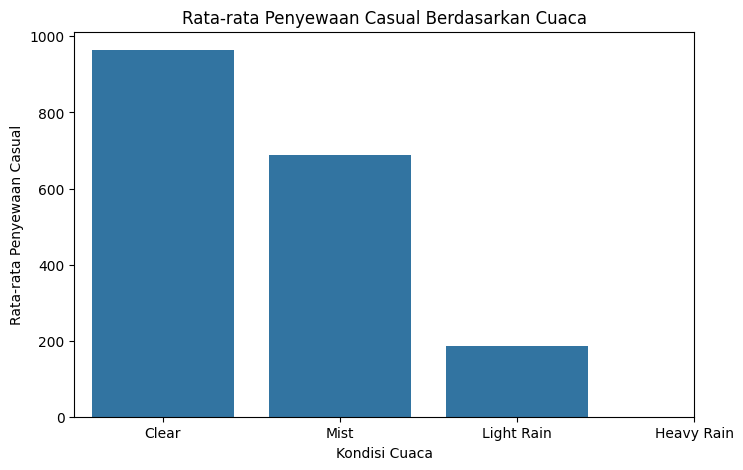

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x=weather_casual.index,y=weather_casual.values)
plt.xticks(
    [0,1,2,3],
    ["Clear","Mist","Light Rain","Heavy Rain"]
)

plt.title("Rata-rata Penyewaan Casual Berdasarkan Cuaca")
plt.xlabel("Kondisi Cuaca")
plt.ylabel("Rata-rata Penyewaan Casual")
plt.show()

**Insight:**
- Pada kondisi Clear, rata-rata penyewaan oleh pengguna casual mencapai 964 sepeda per hari, namun turun drastis menjadi sekitar 185 sepeda per hari saat Light Rain/Snow, menunjukkan cuaca buruk menjadi faktor utama mempengaruhi penyewaan sepeda oleh pengguna casual.
- Hal ini menegaskan bahwa pelanggan kasual mayoritas menyewa sepeda untuk rekreasi atau jalan-jalan santai, sehingga mereka akan membatalkan niatnya ketika cuaca sedang tidak mendukung.

### Pertanyaan 2: Rata-rata penyewaan pada jam 08.00 dan 17.00

In [ ]:
rush_hour = df_hour[df_hour["hr"].isin([8,17])]
rush_avg = rush_hour.groupby("hr")["cnt"].mean()
rush_avg

,cnt
hr,
8,359.011004
17,461.452055


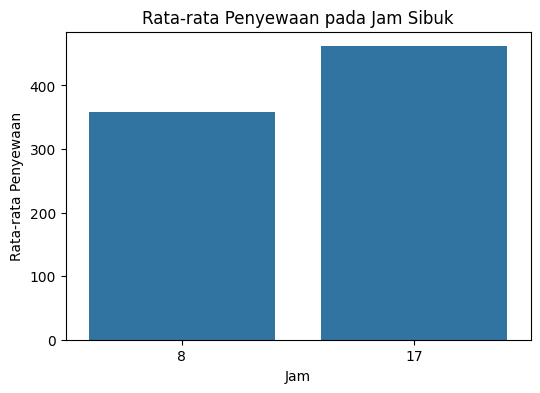

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(x=rush_avg.index,y=rush_avg.values)
plt.title("Rata-rata Penyewaan pada Jam Sibuk")
plt.xlabel("Jam")
plt.ylabel("Rata-rata Penyewaan")
plt.show()

**Insight:**
- Rata-rata penyewaan sepeda pada pukul 17.00 mencapai sekitar 461 sepeda per jam, lebih tinggi dibandingkan pukul 08.00 yang hanya sekitar 359 sepeda, menunjukkan peningkatan sekitar 28% pada jam pulang kerja dibandingkan jam berangkat kerja.
- Pola ini menunjukan bahwa sepeda lebih banyak digunakan sebagai transportasi pulang kerja, sehingga ketersediaan sepeda perlu diprioritaskan pada lokasi strategis menjelang sore hari dijam pulang kerja

### Pertanyaan 3: Jam dengan penyewaan terendah (untuk maintenance)

In [ ]:
hourly_mean = df_hour.groupby("hr")["cnt"].mean()
lowest_hour = hourly_mean.idxmin()
print("Jam dengan penyewaan terendah:", lowest_hour)

Jam dengan penyewaan terendah: 4


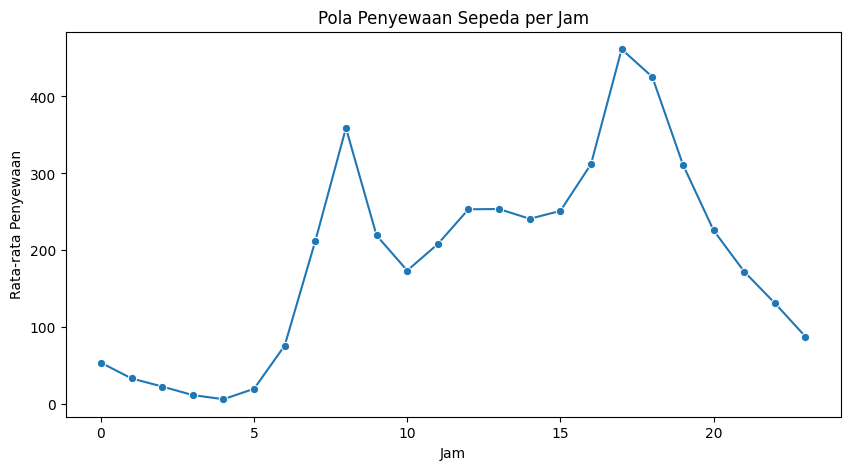

In [ ]:
plt.figure(figsize=(10,5))
sns.lineplot(x=hourly_mean.index,y=hourly_mean.values,marker="o")
plt.title("Pola Penyewaan Sepeda per Jam")
plt.xlabel("Jam")
plt.ylabel("Rata-rata Penyewaan")
plt.show()

**Insight:**
- Tingkat penyewaan sepeda terendah terjadi pada pukul 04.00 pagi, sehingga waktu tersebut merupakan waktu paling optimal untuk melakukan maintenance harian sepeda tanpa mengganggu aktivitas pengguna.
- Karena aktivitas penyewaan mulai meningkat setelah pukul 06.00, maka kegiatan maintenance sebaiknya dijadwalkan pada rentang 03.00-05.00 agar seluruh sepeda sudah siap digunakan saat jam berangkat kerja.

### Pertanyaan 4 : Perbandingan hari kerja vs weekend/holiday

In [ ]:
workingday_rentals = df_day.groupby("workingday")["cnt"].mean()
workingday_rentals

,cnt
workingday,
0,4330.168831
1,4584.820000


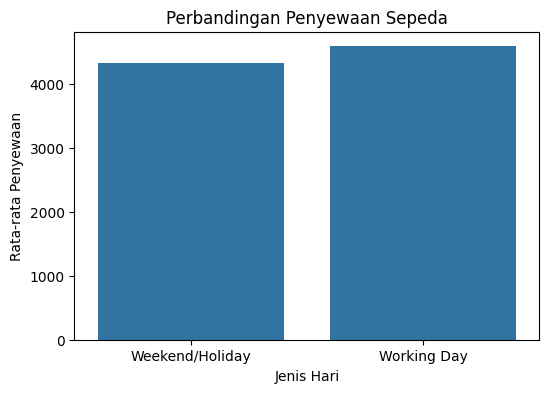

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(x=workingday_rentals.index,y=workingday_rentals.values)
plt.xticks([0,1],["Weekend/Holiday","Working Day"])
plt.title("Perbandingan Penyewaan Sepeda")
plt.xlabel("Jenis Hari")
plt.ylabel("Rata-rata Penyewaan")
plt.show()

**Insight:**
- Rata-rata penyewaan sepeda pada hari kerja mencapai sekitar 4584 sepeda per hari, sedikit lebih tinggi dibandingkan 4330 sepeda pada hari libur atau akhir pekan, menunjukkan bahwa penyewaan sepeda lebih sering digunakan sebagai transportasi rutin dibandingkan rekreasi.
- Perbedaan sekitar 254 sepeda per hari menunjukkan bahwa permintaan tetap stabil sepanjang minggu, sepeda digunakan secara rutin sebagai alat transportasi saat hari kerja, namun tetap digemari sebagai alat rekreasi saat akhir pekan tiba.

### Pertanyaan 5 : Tren pertumbuhan penyewaan 2011 vs 2012

In [ ]:
monthly_trend = df_day.groupby(["yr","mnth"])["cnt"].sum().reset_index()

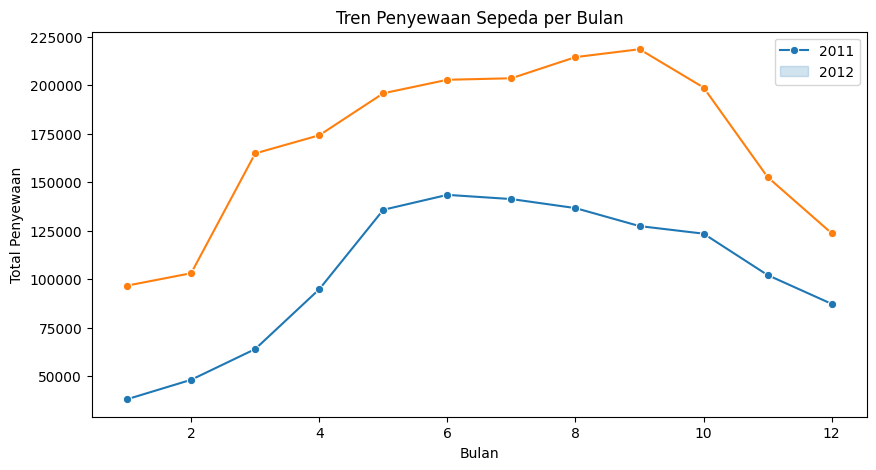

In [ ]:
plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_trend,x="mnth",y="cnt",hue="yr",marker="o")
plt.title("Tren Penyewaan Sepeda per Bulan")
plt.xlabel("Bulan")
plt.ylabel("Total Penyewaan")
plt.legend(labels=["2011","2012"])
plt.show()

**Insight:**
- Total penyewaan sepeda meningkat dari sekitar 1,24 juta pada tahun 2011 menjadi 2,05 juta pada tahun 2012, menunjukkan pertumbuhan penggunaan sebesar sekitar 65% dalam satu tahun.
- Pertumbuhan ini menandakan bahwa layanan penyewaan sepeda semakin dipilih masyarakat, sehingga penewaan dapat mempertimbangkan penambahan jumlah sepeda pada tahun berikutnya untuk mengakomodasi peningkatan permintaan.

## Analisis Lanjutan (Opsional)

### Analisis Korelasi Faktor yang Mempengaruhi Penyewaan

In [ ]:
corr_matrix = df_day[['temp','atemp','hum','windspeed','cnt']].corr()
corr_matrix

,temp,atemp,hum,windspeed,cnt
temp,1.000000,0.991702,0.126963,-0.157944,0.627494
atemp,0.991702,1.000000,0.139988,-0.183643,0.631066
hum,0.126963,0.139988,1.000000,-0.248489,-0.100659
windspeed,-0.157944,-0.183643,-0.248489,1.000000,-0.234545
cnt,0.627494,0.631066,-0.100659,-0.234545,1.000000


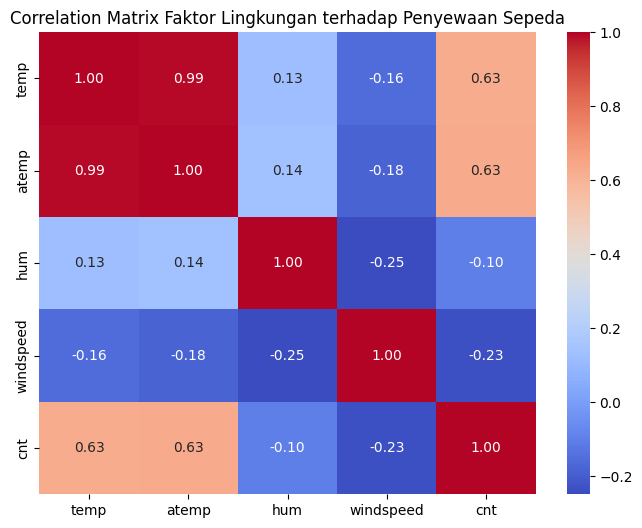

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix Faktor Lingkungan terhadap Penyewaan Sepeda")

plt.show()

**Insight:**
- Suhu (temp dan atemp) memiliki korelasi positif cukup kuat terhadap jumlah penyewaan sepeda dengan nilai sekitar 0.63, menunjukkan bahwa semakin hangat suhu udara maka semakin tinggi pula jumlah sepeda yang disewa.
- Sebaliknya, kecepatan angin (-0.23) dan kelembapan (-0.10) menunjukkan korelasi negatif terhadap jumlah penyewaan, yang mengindikasikan bahwa kondisi cuaca yang kurang nyaman cenderung menurunkan minat masyarakat untuk menggunakan sepeda.

### Analisis Pertumbuhan Tahunan

In [ ]:
yearly_growth = df_day.groupby("yr")["cnt"].sum()
yearly_growth

,cnt
yr,
0,1243103
1,2049576


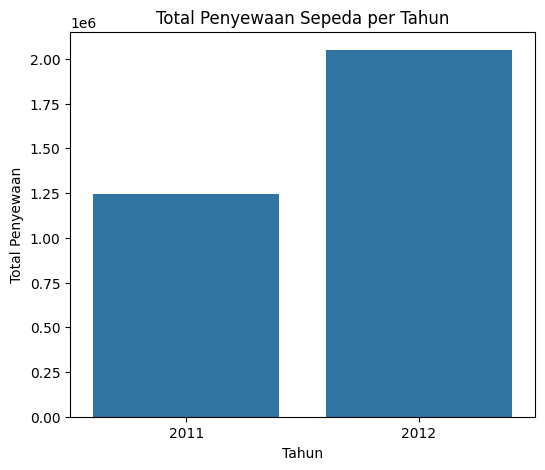

In [ ]:
plt.figure(figsize=(6,5))
sns.barplot(x=yearly_growth.index,y=yearly_growth.values)
plt.xticks([0,1],["2011","2012"])
plt.title("Total Penyewaan Sepeda per Tahun")
plt.xlabel("Tahun")
plt.ylabel("Total Penyewaan")
plt.show()

**Insight:**
- Total penyewaan sepeda meningkat tajam dari sekitar 1,25 juta pada tahun 2011 menjadi lebih dari 2 juta pada tahun 2012, menunjukkan pertumbuhan penggunaan lebih dari 60%.  
- Kenaikan ini menandakan adanya adopsi yang semakin luas terhadap layanan bike-sharing, kemungkinan dipengaruhi oleh meningkatnya kesadaran transportasi ramah lingkungan dan kebutuhan mobilitas perkotaan.  


## Clustering berdasarkan waktu

In [ ]:
def kategori_waktu(hour):
    if 5 <= hour < 12:
        return 'Pagi (05:00 - 11:59)'
    elif 12 <= hour < 17:
        return 'Siang (12:00 - 16:59)'
    elif 17 <= hour < 21:
        return 'Sore (17:00 - 20:59)'
    else:
        return 'Malam (21:00 - 04:59)'


df_hour['time_category'] = df_hour['hr'].apply(kategori_waktu)
time_cluster_df = df_hour.groupby('time_category')['cnt'].sum().sort_values(ascending=False).reset_index()
display(time_cluster_df)

,time_category,cnt
0,Sore (17:00 - 20:59),1037971
1,Siang (12:00 - 16:59),955882
2,Pagi (05:00 - 11:59),921580
3,Malam (21:00 - 04:59),377246


/tmp/ipykernel_197/2994536310.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='time_category',y='cnt',data=time_cluster_df,palette='viridis')


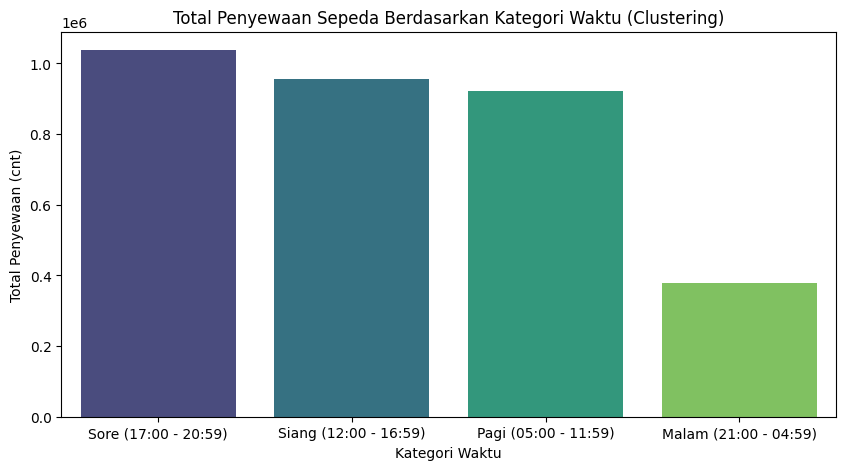

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(x='time_category',y='cnt',data=time_cluster_df,palette='viridis')
plt.title('Total Penyewaan Sepeda Berdasarkan Kategori Waktu (Clustering)')
plt.xlabel('Kategori Waktu')
plt.ylabel('Total Penyewaan (cnt)')
plt.show()

**Insight:**
- Puncak penggunaan terjadi di sore hari total penyewaan mencapai sekitar 1.050.000, lebih tinggi dibanding kategori waktu lainnya. Ini menunjukkan bahwa sore adalah periode paling sibuk, kemungkinan karena orang pulang kerja.
- Pada malam harijauh lebih rendah dibanding periode lain
Dengan total sekitar 380.000, penggunaan sepeda di malam hari hanya sepertiga dari periode pagi/siang/sore.

## Conclusion

- Conclusion Pertanyaan 1 (Pengaruh Cuaca terhadap Pengguna Kasual): Kondisi cuaca memiliki dampak yang sangat signifikan terhadap keputusan pengguna casual. Saat cuaca cerah (Clear/Partly Cloudy), jumlah penyewaan oleh pengguna kasual berada di titik tertinggi. Sebaliknya, saat cuaca ekstrem (Heavy Rain/Snow), jumlah penyewaan turun drastis hingga hampir tidak ada yang menyewa (rata-rata mendekati 0). Kesimpulannya, pengguna casual sangat menghindari bersepeda di cuaca buruk karena tujuan utama mereka cenderung untuk rekreasi atau jalan-jalan santai.

- Conclusion Pertanyaan 2 (Rata-rata Penyewaan Pukul 08.00 vs 17.00):
Pada jam sibuk, rata-rata total penyewaan sepeda di sore hari jauh lebih tinggi dibandingkan pagi hari. Pukul 17.00 sore mencatatkan angka rata-rata sekitar 461 unit sepeda yang disewa, lebih tinggi dibandingkan pukul 08.00 pagi yang mencatatkan rata-rata 359 unit. Hal ini menunjukkan bahwa pada pulang kerja di sore hari lebih padat menggunakan sepeda dibandingkan arus berangkat kerja di pagi hari.

- Conclusion Pertanyaan 3 (Waktu Optimal untuk Maintenance):
Tingkat penyewaan sepeda harian secara konsisten mencapai titik terendahnya pada pukul 04.00 dini hari. Oleh karena itu, rentang waktu antara pukul 03.00 hingga 05.00 pagi adalah waktu yang paling optimal dan minim risiko bagi pihak manajemen untuk melakukan jadwal maintenance (perawatan) sepeda harian tanpa mengganggu pelayanan kepada pelanggan.

- Conclusion Pertanyaan 4 (Pola Hari Libur vs Hari Kerja):
Terdapat perbedaan pola jumlah penyewaan secara rata-rata, di mana hari kerja biasa (Working Day) mencatatkan total penyewaan rata-rata yang lebih tinggi (4.584 unit) dibandingkan dengan hari libur atau akhir pekan (Weekend/Holiday) yang berada di angka 4.330 unit. Angka ini mengindikasikan bahwa secara keseluruhan, sistem bike-sharing ini lebih banyak dimanfaatkan sebagai alat transportasi rutinitas harian untuk bekerja/sekolah ketimbang untuk aktivitas liburan.

- Conclusion Pertanyaan 5 (Tren Pertumbuhan 2011 vs 2012):
Sistem bike-sharing mengalami tren pertumbuhan bisnis yang sangat positif dan konsisten. Sepanjang tahun 2012, jumlah total penyewaan di setiap bulannya selalu berhasil melampaui angka penyewaan pada bulan yang sama di tahun 2011. Selain itu, kedua tahun tersebut menunjukkan pola musiman yang sama, yaitu jumlah penyewaan perlahan naik di awal tahun, memuncak pada pertengahan hingga bulan Juni - September, dan kemudian menurun menjelang akhir tahun karena memasuki musim dingin.